In [1]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

In [2]:
N_sin = 8
task, y_bar = sine_square_input_task(Nsegments = 110, wsin= 10.0, Nsin = N_sin, seed = 1234)

array([1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1],
      dtype=int64)

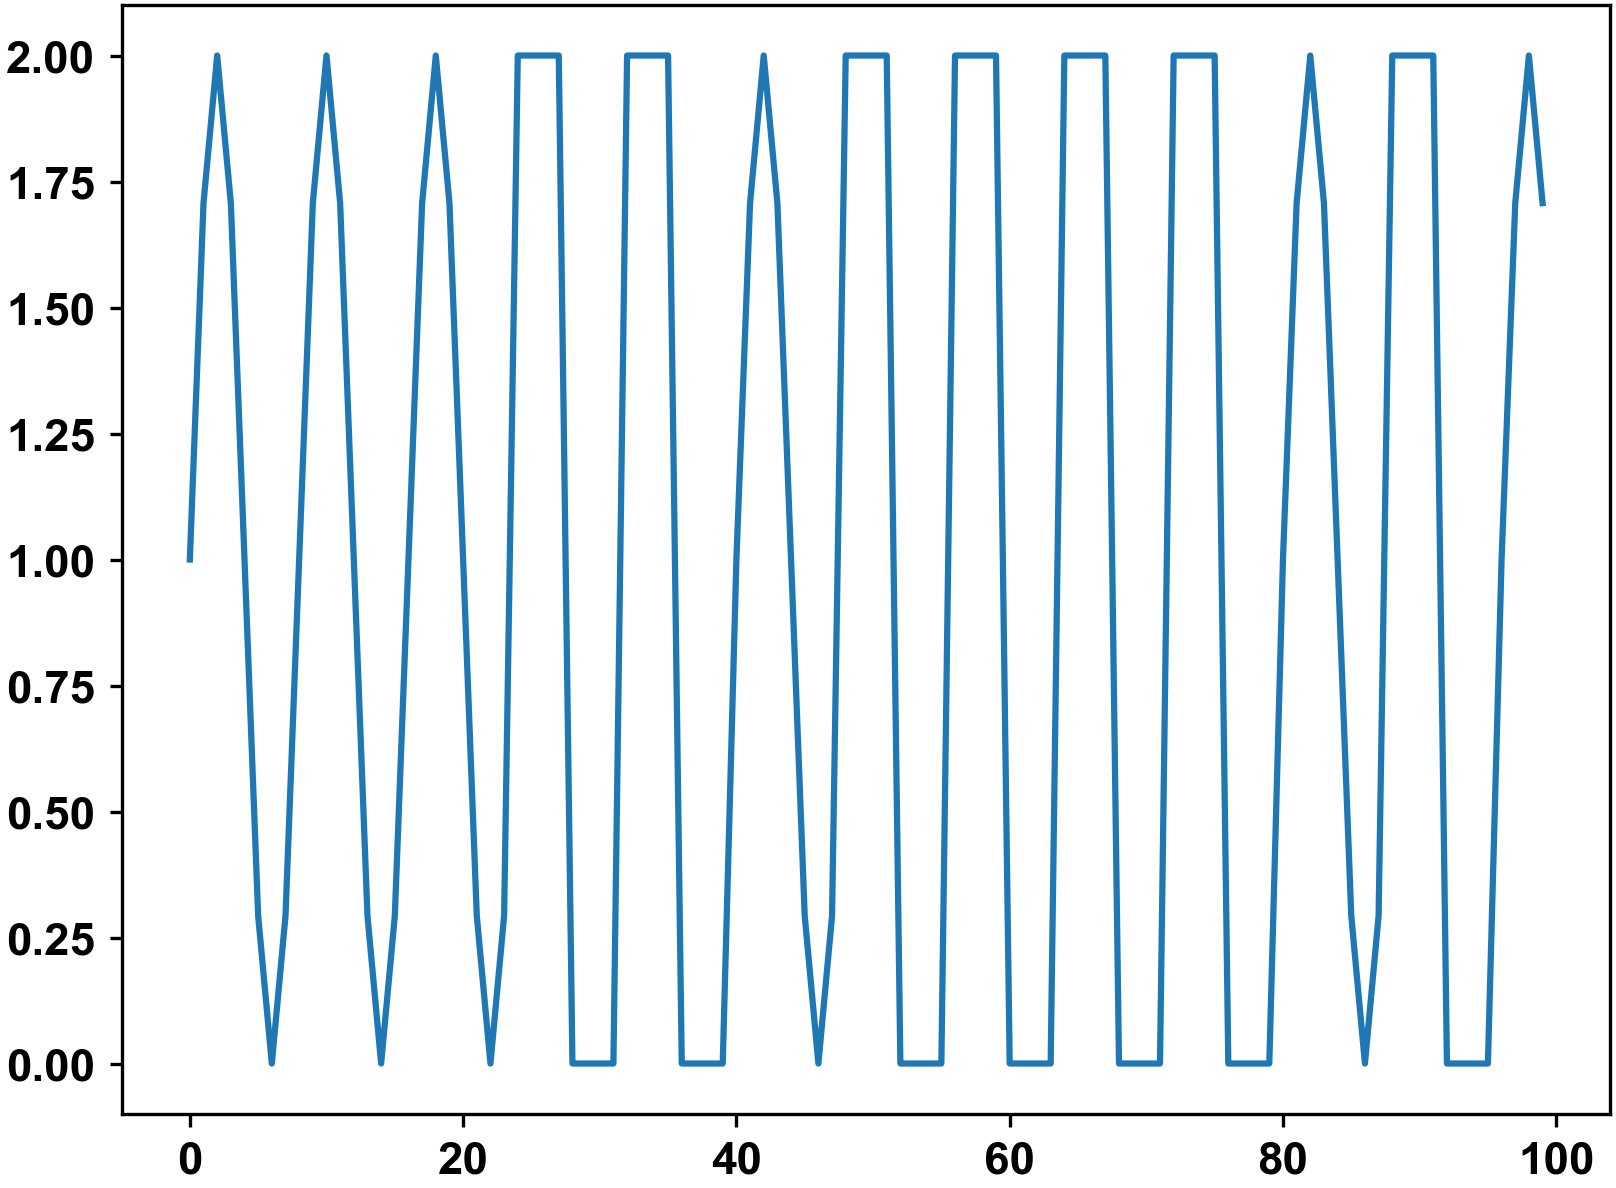

In [3]:
plt.plot(task[:100])
y_bar[::N_sin]

ESN performance

In [5]:
N = 16
A, B = make_esn_weights(
    N,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,)

X = esn_dynamics(task, A, B)
# Generate ESN reservoir states for full time series
X.shape

(880, 16)

NRMSE: 0.1330234812336725


Text(0.5, 1.0, 'BTC Prediction by ESN')

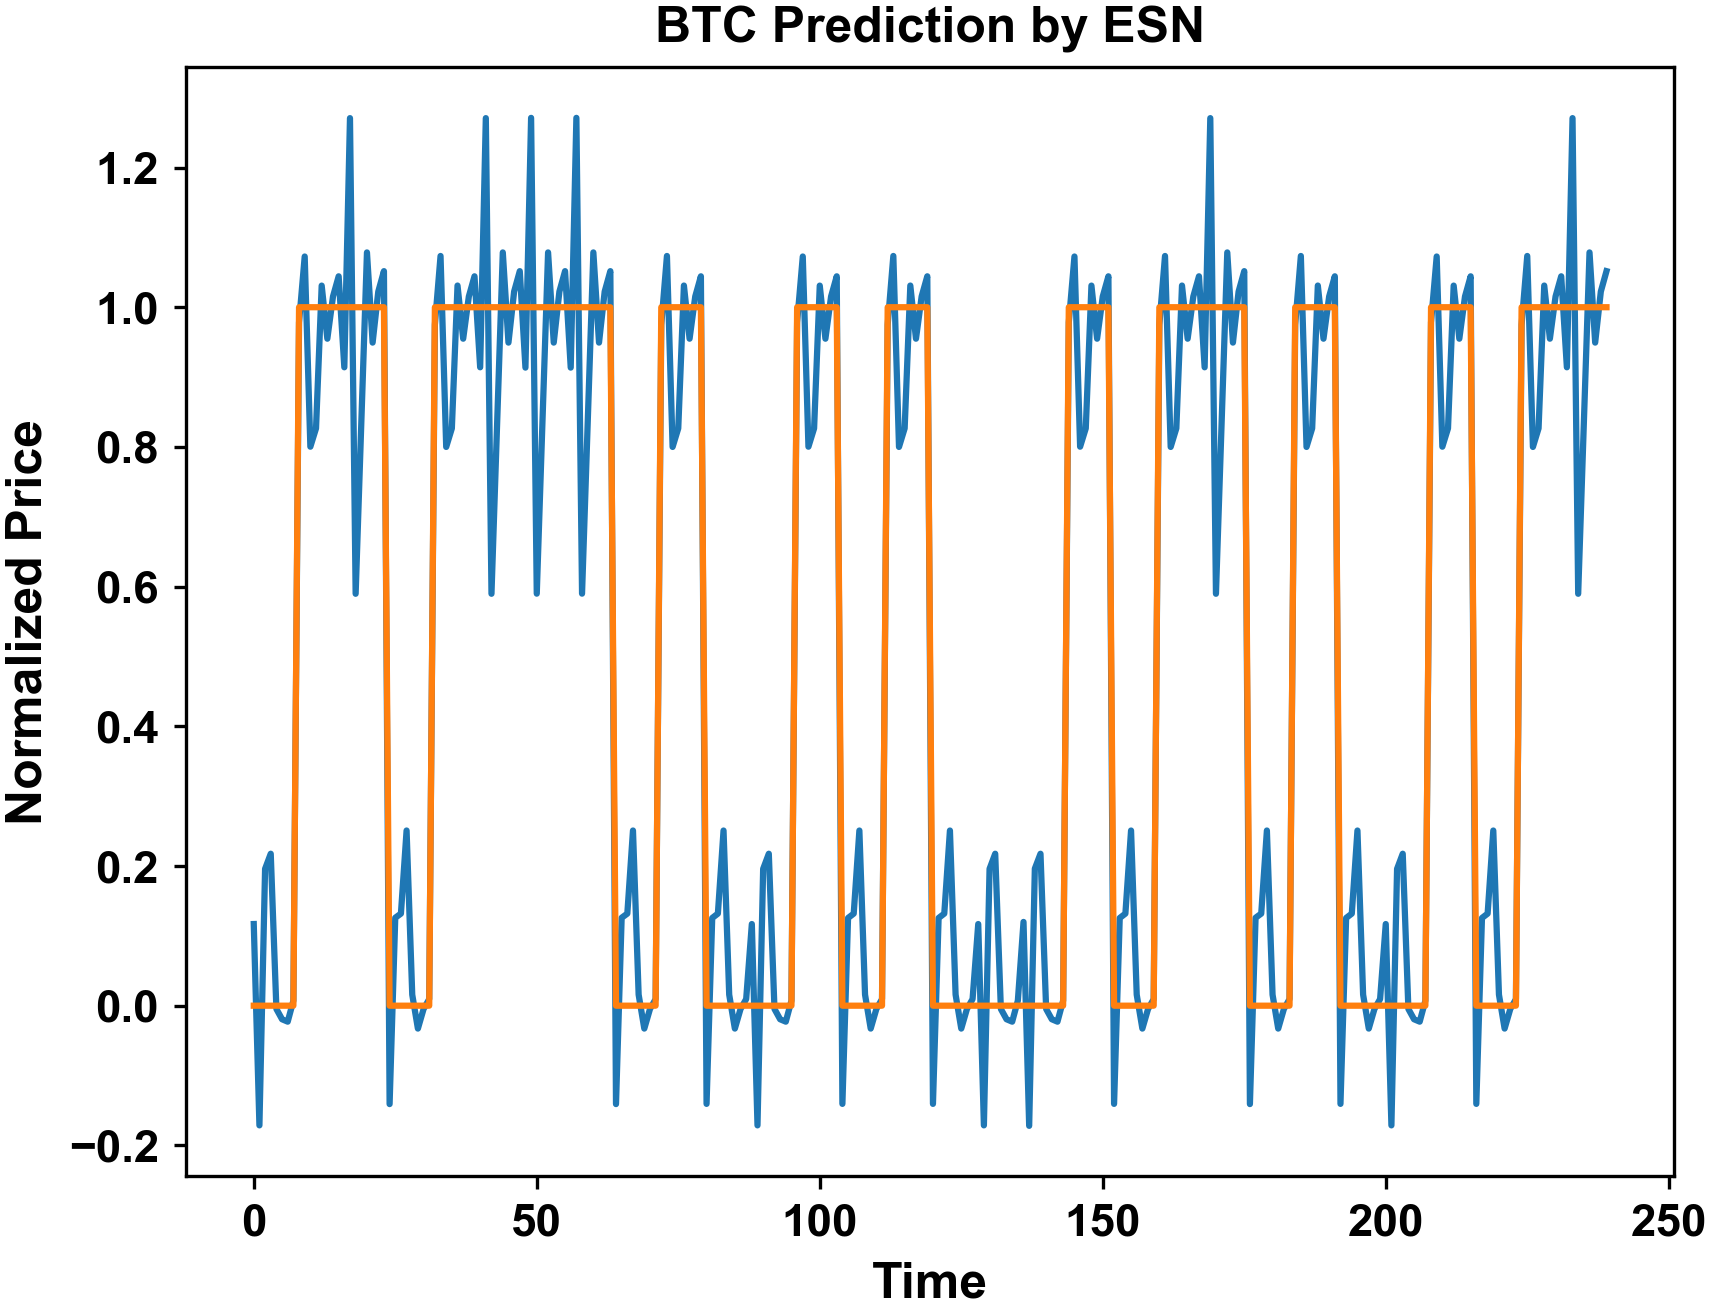

In [6]:
Nfading = 5*N_sin
Ntraining = 75*N_sin 
Ntesting = 110*N_sin-Nfading-Ntraining
X_features = X
X_train = X[Nfading : Nfading + Ntraining, :]
X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = y_bar
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Quantum Performance

In [8]:
N_sin = 8
N = 8
df = pd.read_csv(f"SS{N_sin}sampled_points_rep{N}.csv")
X = extract_block_single_column_pq(df,'PQ0',N_fts=N,n_samples=110*N_sin, skip_steps=1,mode="both")
X = add_polynomial_features(X,N*2)
X.shape

(880, 80)

In [9]:
task, y_bar = sine_square_input_task(Nsegments = 110, wsin= 10.0, Nsin = N_sin, seed = 1234)

NRMSE: 0.052072464693473645


Text(0.5, 1.0, 'BTC Prediction by ESN')

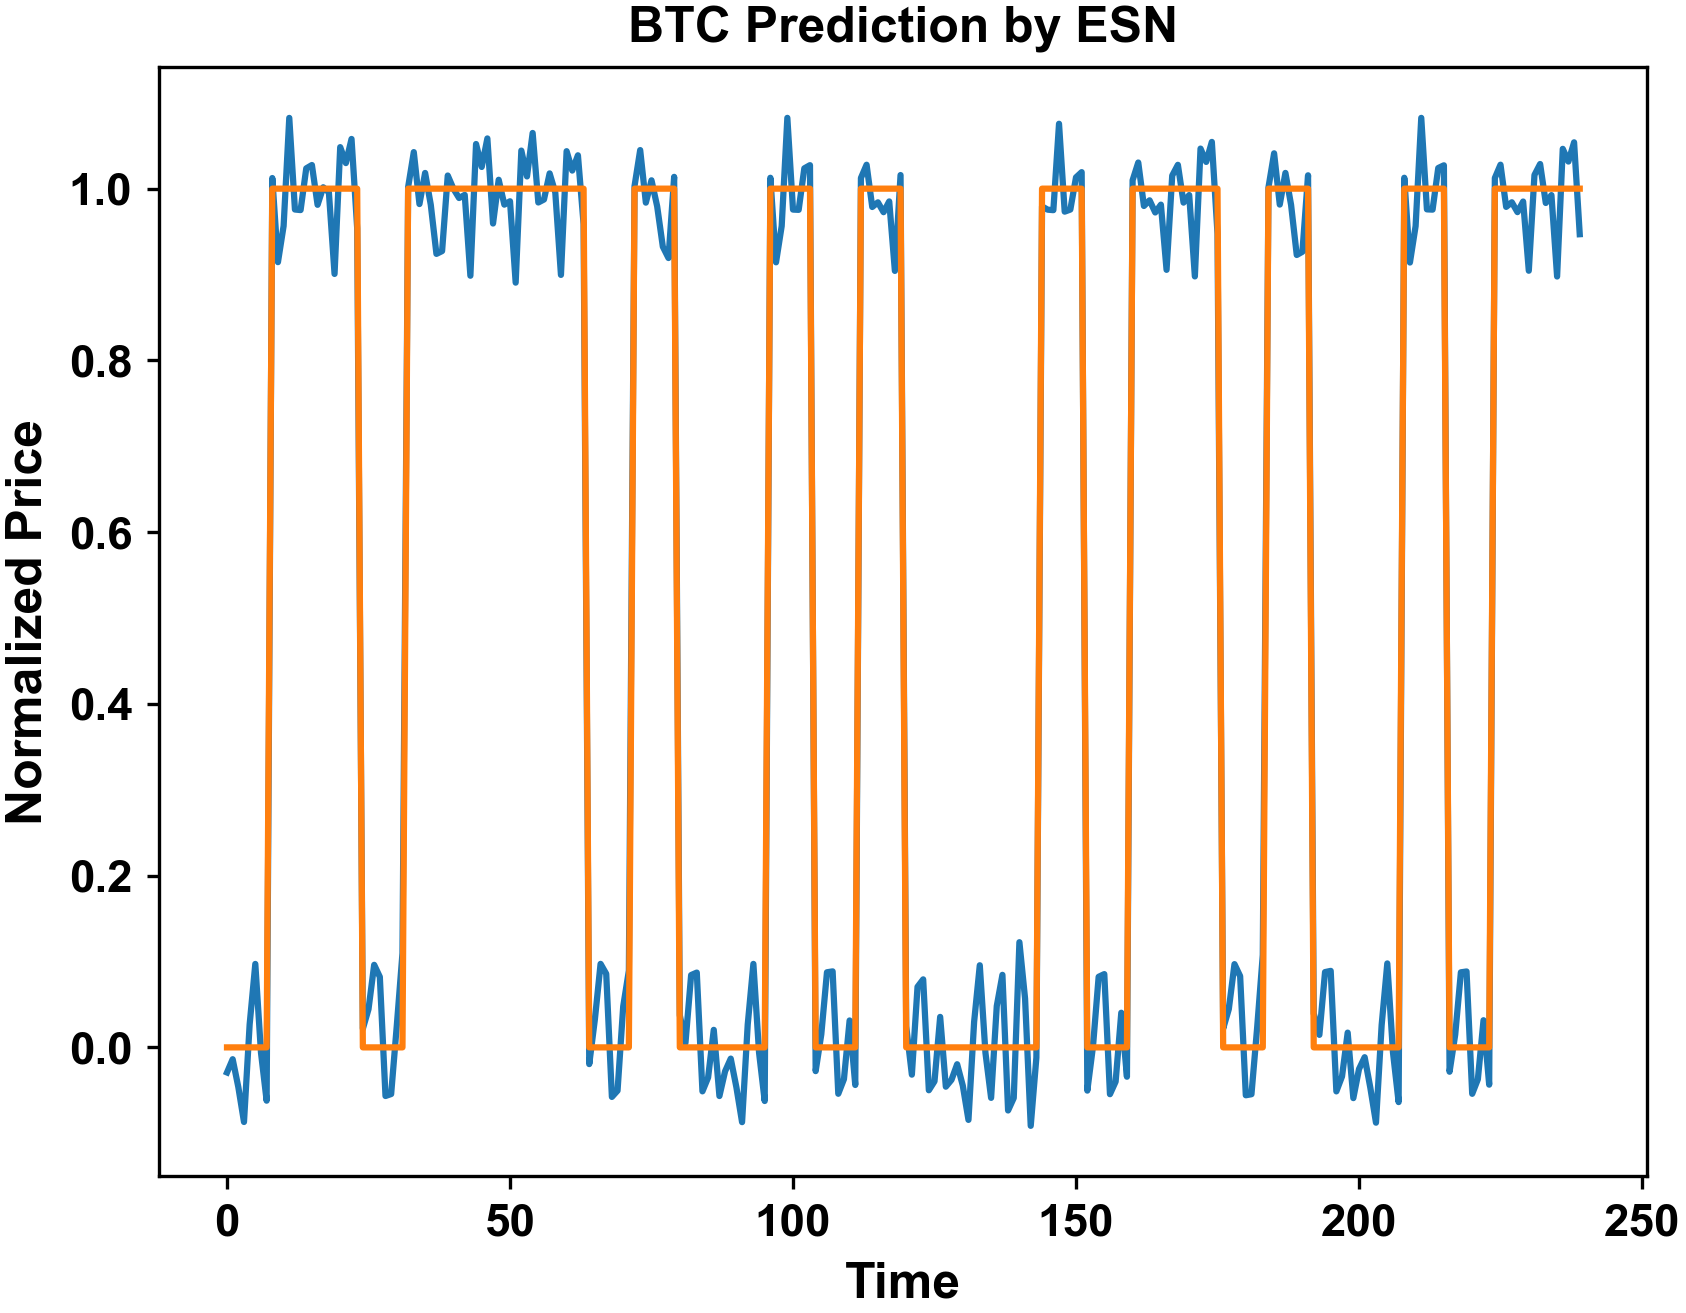

In [10]:
Nfading = 5*N_sin
Ntraining = 75*N_sin 
Ntesting = 110*N_sin-Nfading-Ntraining
X_features = X
X_train = X[Nfading : Nfading + Ntraining, :]
X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = y_bar
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Analyzing on multiple runs

In [12]:
def ESN_performance(node):
    N = node
    A, B = make_esn_weights(
        N,
        input_scale=1.0,
        spectral_radius=0.95,
        connectivity=0.1,)
    X = esn_dynamics(task, A, B)

    Nfading = 5*N_sin
    Ntraining = 75*N_sin 
    Ntesting = 110*N_sin-Nfading-Ntraining
    X_features = X
    X_train = X[Nfading : Nfading + Ntraining, :]
    X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = y_bar
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    W = fitting_function(X_train, y_train)
    y_prediction = predict(X_test, W)
    error = nrmse(y_prediction, y_test)
    print("NRMSE:", error)
    return error

def ESN_performance_repeat(node, n_runs=50):
    errors = []
    for r in range(n_runs):
        error = ESN_performance(node)
        errors.append(error)
    errors = np.array(errors)
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    print(f"Node = {node}")
    print(f"Mean NRMSE = {mean_error}")
    print(f"Std NRMSE  = {std_error}")
    return mean_error, std_error, errors


def NMR_performance(node,XX):
    N = node
    X = XX[:,:node]

    Nfading = 5*N_sin
    Ntraining = 75*N_sin 
    Ntesting = 110*N_sin-Nfading-Ntraining
    X_features = X
    X_train = X[Nfading : Nfading + Ntraining, :]
    X_test = X[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = y_bar
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    W = fitting_function(X_train, y_train)
    y_prediction = predict(X_test, W)
    error = nrmse(y_prediction, y_test)
    print("NRMSE:", error)
    return error

In [13]:
nodes = [i+1 for i in range(50)]
N_sin = 8
N = 8
df = pd.read_csv(f"SS{N_sin}sampled_points_rep{N}.csv")
X = extract_block_single_column_pq(df,'PQ0',N_fts=N,n_samples=110*N_sin, skip_steps=1,mode="both")
X = add_polynomial_features(X,N*2)
ESN_means = []
ESN_stds = []
ESN_all_errors = {}
NMR_errors = []
for node in nodes:
    mean_error, std_error, errors = ESN_performance_repeat(node=node,n_runs=50)
    ESN_means.append(mean_error)
    ESN_stds.append(std_error)
    ESN_all_errors[node] = errors

    NMR_error = NMR_performance(node,X)
    NMR_errors.append(NMR_error)

ESN_means = np.array(ESN_means)
ESN_stds = np.array(ESN_stds)

NRMSE: 0.49819401527069856
NRMSE: 0.4928214222855689
NRMSE: 0.4818388412770514
NRMSE: 0.49830659139966443
NRMSE: 0.4990593168550909
NRMSE: 0.49891788768899936
NRMSE: 0.49847447313254345
NRMSE: 0.4979755838166651
NRMSE: 0.49862816906995205
NRMSE: 0.4947266598897975
NRMSE: 0.49870602715047263
NRMSE: 0.49906579369470133
NRMSE: 0.4956414886565242
NRMSE: 0.4990653991415645
NRMSE: 0.4989805115642693
NRMSE: 0.49487308710471734
NRMSE: 0.49904897679874355
NRMSE: 0.49428732562661454
NRMSE: 0.4989195846334832
NRMSE: 0.49737453688755956
NRMSE: 0.4990542352927837
NRMSE: 0.49906030603541424
NRMSE: 0.49855471554459835
NRMSE: 0.4969499581260648
NRMSE: 0.4941763814812729
NRMSE: 0.49854796404500673
NRMSE: 0.4990026804735394
NRMSE: 0.495339052985634
NRMSE: 0.4952326822016051
NRMSE: 0.49601987982133566
NRMSE: 0.49346021995662165
NRMSE: 0.48883359889723077
NRMSE: 0.4987569272960161
NRMSE: 0.49902287872197726
NRMSE: 0.4972704411008794
NRMSE: 0.49696286285001007
NRMSE: 0.4981504056369231
NRMSE: 0.49906102471

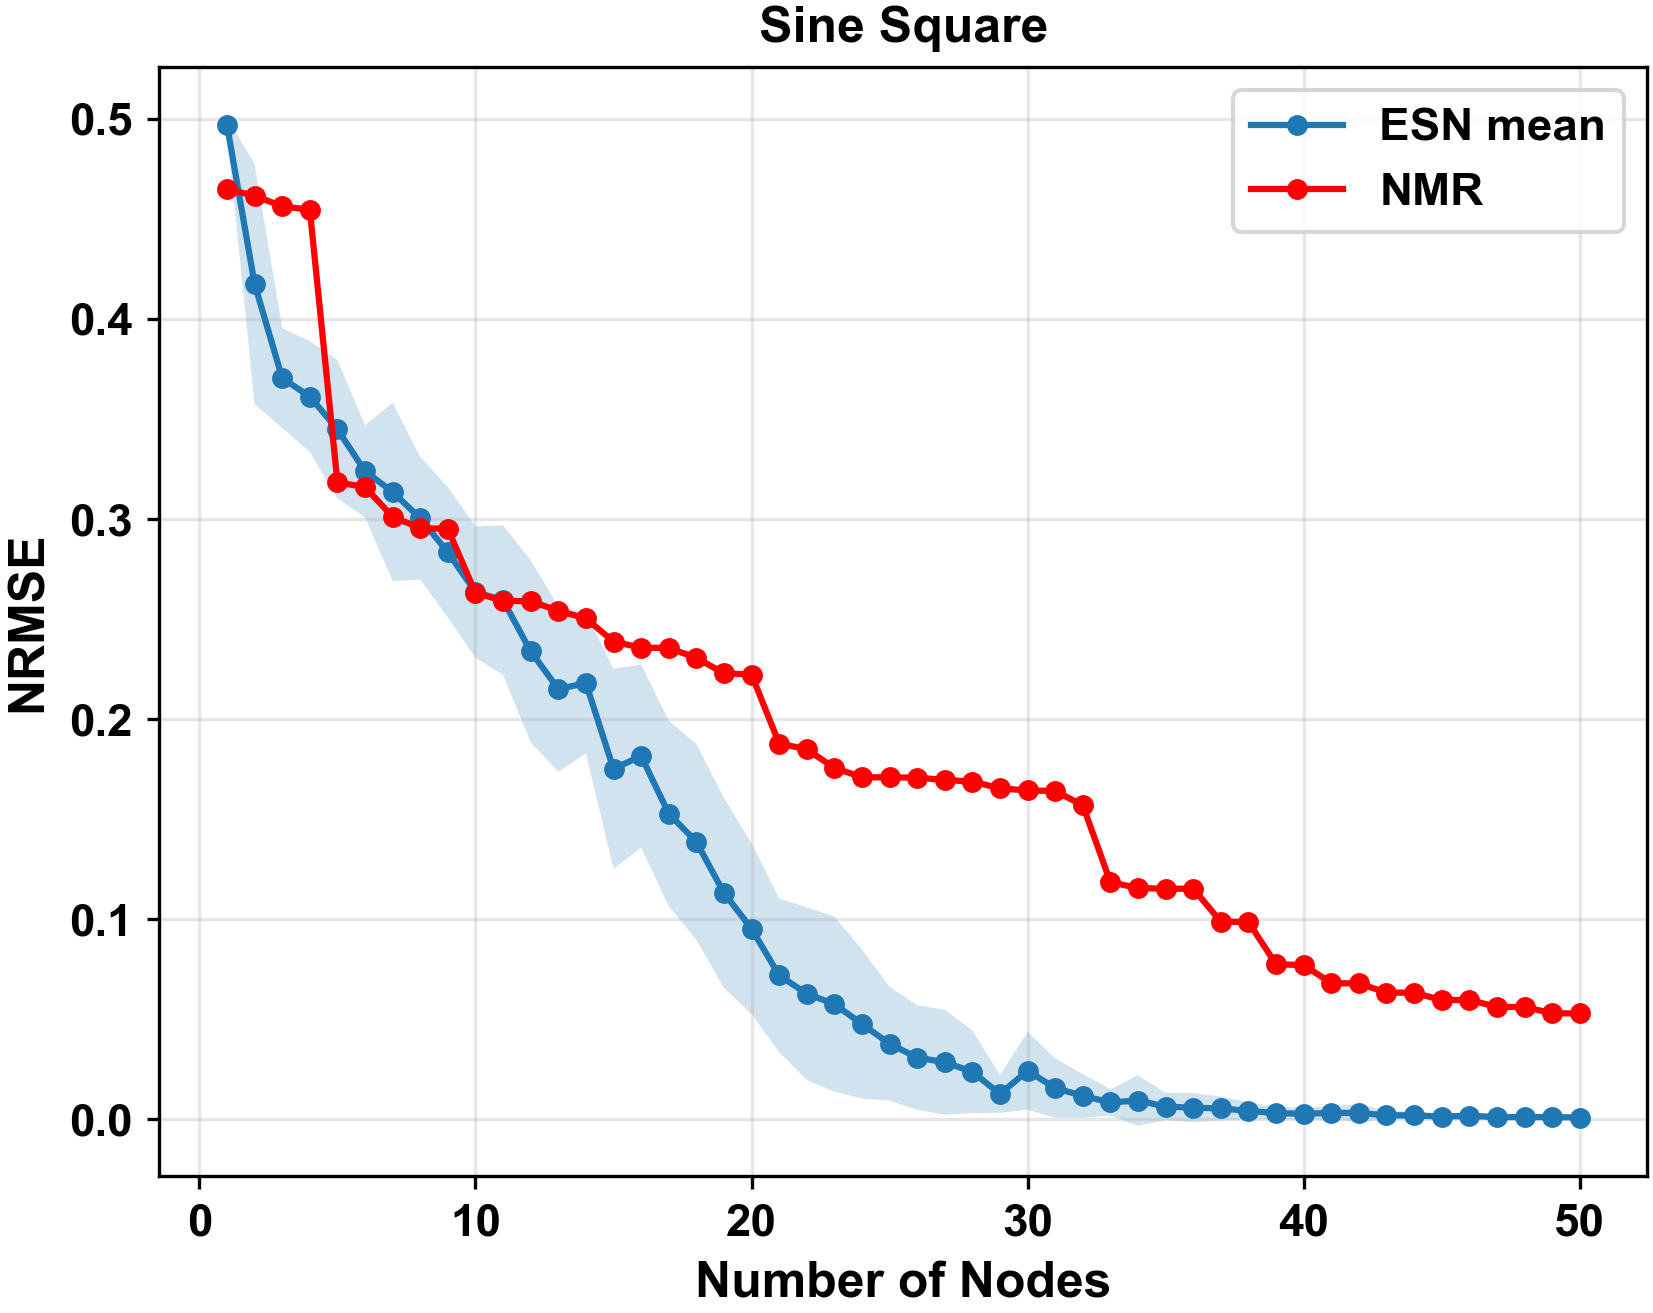

In [36]:
plt.plot(nodes, ESN_means, marker="o", label="ESN mean")
plt.plot(nodes,NMR_errors, marker="o", label='NMR', color='red')
plt.fill_between(nodes,ESN_means - ESN_stds,ESN_means + ESN_stds,
    alpha=0.2)
plt.xlabel("Number of Nodes")
plt.ylabel("NRMSE")
plt.title("Sine Square")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Sinesquare.png')
plt.show()